# Primer — the linear algebra this course leans on

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/primers/linear-algebra.ipynb)

*Orthogonality, eigen/SVD/condition number, effective rank — each with a runnable demo. Optional: read it when a foundations module points here.*


## 1. Orthogonality & orthonormality

The **inner product** $\mathbf u^\top\mathbf v=\sum_i u_i v_i=\lVert\mathbf u\rVert\lVert\mathbf v\rVert\cos\theta$ measures alignment. Two non-zero vectors are **orthogonal** ($\mathbf u\perp\mathbf v$) when $\mathbf u^\top\mathbf v=0$ — i.e. $\theta=90^\circ$, *no shared component*. A set is **orthonormal** when every pair is orthogonal **and** each vector has unit length. An **orthonormal basis** is the nicest coordinate system there is: every vector decomposes as $\mathbf x=\sum_i(\mathbf q_i^\top\mathbf x)\,\mathbf q_i$, and writing along one $\mathbf q_i$ leaves all the others untouched.

**Why the course cares.** An associative memory stores $\mathcal M=\sum_i\mathbf v_i\mathbf k_i^\top$ and reads with $\mathcal M\mathbf k_j=\sum_i\mathbf v_i(\mathbf k_i^\top\mathbf k_j)$. If the keys are **orthonormal**, every cross term $\mathbf k_i^\top\mathbf k_j$ ($i\neq j$) is $0$ and you get back exactly $\mathbf v_j$ — **perfect recall**. The moment keys overlap, those cross terms leak other values into the answer: **crosstalk**.

In [1]:
import numpy as np
np.random.seed(0)
d, N = 8, 8

# orthonormal keys (columns of a random orthogonal matrix) vs correlated keys (clustered)
Q = np.linalg.qr(np.random.randn(d, d))[0]
keys_on = Q[:, :N]
base = np.random.randn(d); base /= np.linalg.norm(base)
keys_corr = np.stack([(lambda k: k/np.linalg.norm(k))(base + 0.6*np.random.randn(d)) for _ in range(N)], 1)
vals = np.random.randn(N, d)

def recall_err(K):
    M = sum(np.outer(vals[i], K[:, i]) for i in range(N))    # M = Σ vᵢ kᵢᵀ
    return np.mean([np.linalg.norm(M @ K[:, i] - vals[i]) for i in range(N)])
def max_offdiag(K):
    G = np.abs(K.T @ K); np.fill_diagonal(G, 0); return G.max()   # largest |kᵢ·kⱼ|, i≠j

print(f"orthonormal keys : max |kᵢ·kⱼ| = {max_offdiag(keys_on):.3f}   mean recall err = {recall_err(keys_on):.4f}")
print(f"correlated keys  : max |kᵢ·kⱼ| = {max_offdiag(keys_corr):.3f}   mean recall err = {recall_err(keys_corr):.4f}")
print("→ orthonormal: zero cross terms → perfect recall.  correlated: cross terms leak → crosstalk.")

orthonormal keys : max |kᵢ·kⱼ| = 0.000   mean recall err = 0.0000
correlated keys  : max |kᵢ·kⱼ| = 0.866   mean recall err = 2.9458
→ orthonormal: zero cross terms → perfect recall.  correlated: cross terms leak → crosstalk.


The same fact, stated for *writing*: storing a new association along a direction orthogonal to an old one **does not disturb** the old readout. Overlap is exactly what causes interference — and, one level up, what makes "orthogonal tasks" the hardest case for an optimizer's memory (M6 §2.1).

In [2]:
import numpy as np

np.random.seed(0)
d = 8
Q = np.linalg.qr(np.random.randn(d, d))[0]
k1 = Q[:, 0]
v1, v2 = np.random.randn(d), np.random.randn(d)
for name, k2 in [("k2 ⟂ k1", Q[:, 1]), ("k2 overlaps k1", (k1 + 0.5 * Q[:, 2]) / np.linalg.norm(k1 + 0.5 * Q[:, 2]))]:
    M = np.outer(v1, k1) + np.outer(v2, k2)  # store v1@k1, then also v2@k2
    print(f"{name:<16}: cos(k1,k2)={k1 @ k2:+.2f}   ‖readout(k1) − v1‖ = {np.linalg.norm(M @ k1 - v1):.4f}")
print("→ an orthogonal second write is invisible to the first key; an overlapping one corrupts it.")

k2 ⟂ k1         : cos(k1,k2)=+0.00   ‖readout(k1) − v1‖ = 0.0000
k2 overlaps k1  : cos(k1,k2)=+0.89   ‖readout(k1) − v1‖ = 1.9282
→ an orthogonal second write is invisible to the first key; an overlapping one corrupts it.


## 2. Eigenvalues, SVD, and the condition number

A matrix *stretches* space by different amounts along different directions.

- For a **symmetric** matrix $A$ (e.g. a curvature/Hessian), the **eigen-decomposition** $A=\sum_i\lambda_i\mathbf q_i\mathbf q_i^\top$ gives orthonormal directions $\mathbf q_i$ each scaled by an eigenvalue $\lambda_i$.
- For a **general** matrix $M$, the **SVD** $M=U\Sigma V^\top$ does the same with **singular values** $\sigma_i\ge0$ (the $\sigma_i$ are the square roots of the eigenvalues of $M^\top M$).
- The **condition number** $\kappa=\sigma_{\max}/\sigma_{\min}$ (or $\lambda_{\max}/\lambda_{\min}$) measures how *lopsided* the stretch is. $\kappa=1$ = stretches everything equally (a sphere stays a sphere); large $\kappa$ = a long thin ellipse.

**Where this bites in the course.** On a quadratic loss $\tfrac12\mathbf w^\top A\mathbf w$, gradient descent must keep its step size safe for the steepest direction ($\lambda_{\max}$), so it crawls along the flattest one ($\lambda_{\min}$): its convergence rate is $\tfrac{\kappa-1}{\kappa+1}$, which $\to1$ (no progress) as $\kappa$ grows. That is the **zig-zag**, and it is *the* problem momentum and preconditioning exist to fix (M6).

κ=  1.0: rate (κ-1)/(κ+1) = 0.000   steps to loss<1e-8 = 1
κ= 20.0: rate (κ-1)/(κ+1) = 0.905   steps to loss<1e-8 = 120
κ=100.0: rate (κ-1)/(κ+1) = 0.980   steps to loss<1e-8 = 640


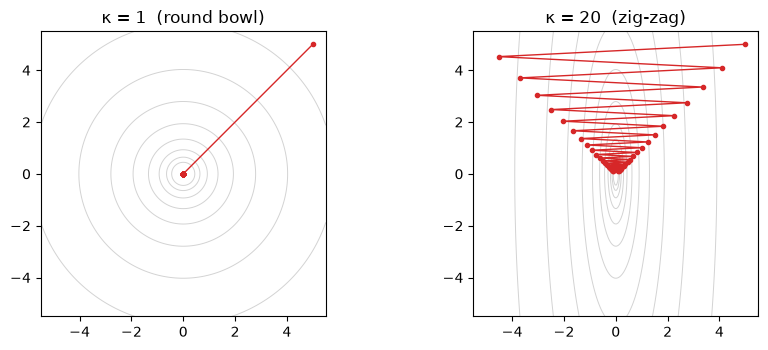

In [ ]:
import numpy as np, matplotlib.pyplot as plt


def gd_path(kappa, steps, th=1e-12):
    A = np.diag([kappa, 1.0])
    w = np.array([5.0, 5.0])
    lr = 2 / (kappa + 1)
    path = [w.copy()]
    n = None
    for t in range(steps):
        w = w - lr * (A @ w)
        path.append(w.copy())
        if n is None and 0.5 * w @ A @ w < 1e-8:
            n = t + 1
    return np.array(path), n


for kappa in [1.0, 20.0, 100.0]:
    _, n = gd_path(kappa, 2000)
    print(f"κ={kappa:>5}: rate (κ-1)/(κ+1) = {(kappa - 1) / (kappa + 1):.3f}   steps to loss<1e-8 = {n}")

# visualize the zig-zag: ill-conditioned (κ=20) vs round bowl (κ=1)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, kappa in zip(axes, [1.0, 20.0]):
    A = np.diag([kappa, 1.0])
    path, _ = gd_path(kappa, 40)
    xs = np.linspace(-5.5, 5.5, 200)
    ys = np.linspace(-5.5, 5.5, 200)
    X, Y = np.meshgrid(xs, ys)
    Z = 0.5 * (kappa * X**2 + Y**2)
    ax.contour(X, Y, Z, levels=np.logspace(-1, 2.5, 12), colors="lightgray", linewidths=0.7)
    ax.plot(path[:, 0], path[:, 1], "-o", ms=3, lw=1, color="C3")
    ax.set_title(f"κ = {kappa:g}" + ("  (round bowl)" if kappa == 1 else "  (zig-zag)"))
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

**Whitening / orthogonalization.** Many fixes amount to *reshaping the ellipse back into a sphere* — mapping all singular values toward $1$, i.e. driving $\kappa\to1$. Adam and Newton do it with a preconditioner; **Muon / Atlas** do it directly on a matrix with the **Newton–Schulz** iteration, an approximate orthogonalization that pushes every $\sigma_i\to1$ without ever forming the SVD (NL-1 §Atlas, M6 §4).

In [ ]:
import numpy as np

np.random.seed(0)
M = np.random.randn(6, 6)
sv = np.linalg.svd(M, compute_uv=False)
print(f"singular values   : {np.round(sv, 3)}")
print(f"condition number κ : {sv.max() / sv.min():.2f}")


def newton_schulz(G, k=5):  # approximate orthogonalization (no SVD)
    a, b, c = 3.4445, -4.7750, 2.0315
    X = G / np.linalg.norm(G)
    for _ in range(k):
        AX = X @ X.T
        X = a * X + b * (AX @ X) + c * (AX @ AX @ X)
    return X


sw = np.linalg.svd(newton_schulz(M), compute_uv=False)
print(
    f"after Newton–Schulz: σ ∈ [{sw.min():.3f}, {sw.max():.3f}]   κ = {sw.max() / sw.min():.2f}   (≈ 1 → ~orthogonal)"
)

singular values   : [4.74  3.348 2.927 1.628 0.931 0.506]
condition number κ : 9.37
after Newton–Schulz: σ ∈ [0.746, 1.134]   κ = 1.52   (≈ 1 → ~orthogonal)


## 3. Rank and *effective* rank = memory capacity

The **rank** of a matrix is the number of independent directions its columns span. But for a memory, the binary "independent or not" is too crude — two keys at $1°$ apart are *technically* independent yet practically the same direction. What matters is the **effective rank**: how many directions are *meaningfully* used. A convenient measure is the **participation ratio** of the singular values,

$$\text{eff.rank}(K)=\frac{\big(\sum_i\sigma_i^2\big)^2}{\sum_i\sigma_i^4},$$

which equals the true count when directions are balanced (orthonormal) and collapses toward $1$ as they pile onto one axis.

**Why the course cares.** This *is* associative-memory capacity (M1, M2): you can store cleanly about as many associations as the **effective rank of the key set** — *not* the nominal matrix rank. Below, eight keys with full matrix-rank 8 but effective rank ~3 already overflow, exactly like eight near-parallel keys would.

In [ ]:
import numpy as np

np.random.seed(0)
d = 8


def eff_rank(K):
    s = np.linalg.svd(K, compute_uv=False)
    s2 = s**2
    return (s2.sum() ** 2) / (s2**2).sum()


def recall_err(K, vals):
    N = K.shape[1]
    M = sum(np.outer(vals[i], K[:, i]) for i in range(N))
    return np.mean([np.linalg.norm(M @ K[:, i] - vals[i]) for i in range(N)])


Q = np.linalg.qr(np.random.randn(d, d))[0]
print(f"{'key set':<30}{'#keys':>6}{'matrix rank':>13}{'eff. rank':>11}{'recall err':>12}")
for N in [4, 8]:  # orthonormal, within capacity
    K = Q[:, :N]
    vals = np.random.randn(N, d)
    print(
        f"{'orthonormal (⟂)':<30}{N:>6}{np.linalg.matrix_rank(K):>13}{eff_rank(K):>11.2f}{recall_err(K, vals):>12.4f}"
    )
base = np.random.randn(d)
base /= np.linalg.norm(base)  # correlated: full matrix-rank, low eff-rank
K = np.stack([(lambda k: k / np.linalg.norm(k))(base + 0.6 * np.random.randn(d)) for _ in range(8)], 1)
print(
    f"{'correlated (clustered)':<30}{8:>6}{np.linalg.matrix_rank(K):>13}{eff_rank(K):>11.2f}{recall_err(K, np.random.randn(8, d)):>12.4f}"
)
K = np.random.randn(d, 14)
K /= np.linalg.norm(K, axis=0)  # over capacity: N > d
print(
    f"{'random, OVER capacity (N>d)':<30}{14:>6}{np.linalg.matrix_rank(K):>13}{eff_rank(K):>11.2f}{recall_err(K, np.random.randn(14, d)):>12.4f}"
)
print("\n→ clean recall tracks EFFECTIVE rank, not matrix rank: full-rank-but-correlated keys still overflow.")

key set                        #keys  matrix rank  eff. rank  recall err
orthonormal (⟂)                    4            4       4.00      0.0000
orthonormal (⟂)                    8            8       8.00      0.0000
correlated (clustered)             8            8       2.91      4.0796
random, OVER capacity (N>d)       14            8       5.17      3.9580

→ clean recall tracks EFFECTIVE rank, not matrix rank: full-rank-but-correlated keys still overflow.


## Where these come back

- **[M1 — Associative memory](../foundations/m1-associative-memory.ipynb)** — orthonormal keys → clean recall; capacity ≈ effective rank of the key set (§1, §3).
- **[M2 — Fast Weight Programmers](../foundations/m2-fast-weight-programmers.ipynb)** — capacity law $\approx d_{\text{key}}$ is the same effective-rank statement (§3).
- **[M3 — Linear attention](../foundations/m3-linear-attention.ipynb)** — the feature map $\phi$ raises the effective dimension of the keys to buy capacity; softmax's infinite-dim kernel is the orthogonality limit (§1, §3).
- **[M6 — Optimizers as associative memories](../foundations/m6-optimizers-as-memory.ipynb)** — ill-conditioning → zig-zag that momentum smooths (§2); orthogonal tasks = worst-case forgetting (§1); Muon = orthogonalizing the gradient (§2); Adam/preconditioning drive $\kappa\to1$ (§2).
- **[Nested Learning · NL-1 — Test-time learning](../tracks/nested-learning/nl1-test-time-learning.ipynb)** — Atlas's Newton–Schulz orthogonalization (whitening the update, $\kappa\to1$) (§2).